In [137]:

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [226]:
import numpy as np

In [138]:
event_labels = {'boogaloo': 'political',
 'boulderfire': 'disaster',
 'buffaloshooting': 'violence',
 'coupdc': 'political',
 'elpaso': 'violence',
 'floodtx': 'disaster',
 'hawaiifires': 'disaster',
 'helene': 'disaster',
 'lewiston': 'violence',
 'montereypark': 'violence',
 'socalfires': 'disaster',
 'uvalde': 'violence',
 'virginiabeach': 'violence',
 'vehiclela': 'violence'}

In [139]:
events_org = {
    'violence': ['boulderfire', 'buffaloshooting', 'elpaso',
                 'montereypark', 'uvalde', 'virginiabeach', 'vehiclela'],
    'disaster': ['floodtx', 'hawaiifires', 'helene', 'socalfires']
}


In [140]:
violence_dfs = []
disaster_dfs = []

In [ ]:
data_id = "hits=2"
datasets_dir = Path(f"output/{data_id}/")

datasets = [d.name for d in datasets_dir.iterdir() if d.is_dir()]

data = []  # Store dataset results from temporal analysis
xlim = (-7,30)  # Define plot limits

# remove if present (avoid ValueError if missing)
for rm in ["lewiston", "boulderfire", "floodtx"]:
    if rm in datasets:
        datasets.remove(rm)

# Collect frames in lists, then concat once at end (fast + correct)
v_neg7, v_onset, v_pos4, v_pos5, v_pos24 = [], [], [], [], []
d_neg7, d_onset, d_pos4, d_pos5, d_pos24 = [], [], [], [], []

for dataset in datasets:
    data_dir = datasets_dir / dataset
    words_counts_dir = data_dir / "words_counts" / "event"

    # Load daily files
    neg7  = pd.read_csv(words_counts_dir / "day_-7.csv")
    onset = pd.read_csv(words_counts_dir / "day_0.csv")
    pos4  = pd.read_csv(words_counts_dir / "day_4.csv")
    pos5  = pd.read_csv(words_counts_dir / "day_5.csv")
    pos24 = pd.read_csv(words_counts_dir / "day_24.csv")

    # Add identifiers (helps later)
    for df_, day in [(neg7, -7), (onset, 0), (pos4, 4), (pos5, 5), (pos24, 24)]:
        df_["dataset"] = dataset
        df_["day"] = day

    # Assign to violence vs disaster
    if dataset in events_org["violence"]:
        v_neg7.append(neg7)
        v_onset.append(onset)
        v_pos4.append(pos4)
        v_pos5.append(pos5)
        v_pos24.append(pos24)
    elif dataset in events_org["disaster"]:
        d_neg7.append(neg7)
        d_onset.append(onset)
        d_pos4.append(pos4)
        d_pos5.append(pos5)
        d_pos24.append(pos24)
    else:
        # dataset not categorized; skip or handle as you like
        print(f"Skipping (not in events_org): {dataset}")

# Final combined DataFrames
v_tot_neg7  = pd.concat(v_neg7,  ignore_index=True) if v_neg7 else pd.DataFrame()
v_tot_onset = pd.concat(v_onset, ignore_index=True) if v_onset else pd.DataFrame()
v_tot_pos4  = pd.concat(v_pos4,  ignore_index=True) if v_pos4 else pd.DataFrame()
v_tot_pos5  = pd.concat(v_pos5,  ignore_index=True) if v_pos5 else pd.DataFrame()
v_tot_pos24 = pd.concat(v_pos24, ignore_index=True) if v_pos24 else pd.DataFrame()

d_tot_neg7  = pd.concat(d_neg7,  ignore_index=True) if d_neg7 else pd.DataFrame()
d_tot_onset = pd.concat(d_onset, ignore_index=True) if d_onset else pd.DataFrame()
d_tot_pos4  = pd.concat(d_pos4,  ignore_index=True) if d_pos4 else pd.DataFrame()
d_tot_pos5  = pd.concat(d_pos5,  ignore_index=True) if d_pos5 else pd.DataFrame()
d_tot_pos24 = pd.concat(d_pos24, ignore_index=True) if d_pos24 else pd.DataFrame()


    

Skipping (not in events_org): boogaloo


In [159]:
# remove if present
for rm in ["lewiston", "boulderfire", "floodtx"]:
    if rm in datasets:
        datasets.remove(rm)

violence_rows = []
disaster_rows = []

for dataset in datasets:
    data_dir = datasets_dir / dataset
    words_counts_dir = data_dir / "words_counts" / "event"

    day_files = {
        -7: "day_-7.csv",
         0: "day_0.csv",
         4: "day_4.csv",
         5: "day_5.csv",
        24: "day_24.csv"
    }

    for day, fname in day_files.items():
        df = pd.read_csv(words_counts_dir / fname)

        # add metadata
        df["dataset"] = dataset
        df["day"] = day

        if dataset in events_org["violence"]:
            df["group"] = "violence"
            violence_rows.append(df)

        elif dataset in events_org["disaster"]:
            df["group"] = "disaster"
            disaster_rows.append(df)

# Final collapsed DataFrames
violence_df = pd.concat(violence_rows, ignore_index=True)
disaster_df = pd.concat(disaster_rows, ignore_index=True)

In [199]:

output_dir = Path(f"results/")

In [201]:
disaster_df.to_csv(output_dir.joinpath("disaster_words_counts.csv"), index=None)

In [218]:
disaster_df

,day,word,count,tfidf,dataset,group,word_norm
0,-7,accept tennessee,1,0.004162,helene,disaster,accept tennessee
1,-7,accept tennessee mansion,1,0.004162,helene,disaster,accept tennessee mansion
2,-7,accountable,3,0.005933,helene,disaster,accountable
3,-7,accountable deal,1,0.001978,helene,disaster,accountable deal
4,-7,accountable deal dave,1,0.001978,helene,disaster,accountable deal dave
...,...,...,...,...,...,...,...
4386,24,work nurse,1,0.001935,socalfires,disaster,work nurse
4387,24,work nurse kaiser,1,0.001935,socalfires,disaster,work nurse kaiser
4388,24,world,1,0.004572,socalfires,disaster,world
4389,24,year,5,0.024225,socalfires,disaster,year


In [204]:
collapse_map_v = {
    # --- Locations / Events ---
    "el paso": ["el paso", "el", "paso"],
    "new york": ["new york", "york", "york city", "new"],
    "texas": ["tx", "texas"],
    "uvalde": ["uvalde", "uvalde texas"],
    "buffalo": ["buffalo", "buffaloshooting", "buffalo new york"],
    "virginia beach": ["virginia", "virginia beach"],
    "monterey park": ["monterey", "monterey park"],

    # --- Schools / Venues ---
    "elementary school": ["elementary", "elementary school", "uvalde elementary"],
    "school": ["school", "high school", "middle school", "campus"],
    "church": ["church", "synagogue", "mosque", "temple"],
    "supermarket": ["supermarket", "grocery", "grocery store", "market"],
    "nightclub": ["nightclub", "club"],

    # --- Violence Phrases ---
    "mass shooting": ["mass", "mass shooting", "mass-shooting"],
    "shooting": ["shooting", "shoot", "shot", "gunfire"],
    "gunman": ["gunman", "shooter", "suspect"],
    "victims": ["victim", "victims"],
    "fatalities": ["dead", "death", "deaths", "fatality", "fatalities", "killed"],

    # --- Law Enforcement / Response ---
    "police": ["police", "cops", "law enforcement"],
    "arrest": ["arrest", "arrested", "custody"],
    "charges": ["charge", "charges", "charged"],
    "president" : ["trump", "biden", "president"],

    # --- Weapons ---
    "firearm": ["gun", "guns", "firearm", "firearms", "weapon", "weapons"],
    "rifle": ["rifle", "ar-15", "ar15"],
}

# Build reverse lookup once
variant_to_canonical = {
    v.lower(): canonical
    for canonical, variants in collapse_map_v.items()
    for v in variants
}

def normalize_word(w):
    # Handle NaN / non-strings safely
    if pd.isna(w):
        return w  # keep NaN (or return "" if you prefer)
    w = str(w).lower().strip()
    return variant_to_canonical.get(w, w)

# Apply
violence_df["word_norm"] = violence_df["word"].apply(normalize_word)

In [205]:
top50_violence = (
    violence_df[violence_df["group"] == "violence"]
    .groupby("word_norm", as_index=False)
    .agg({
        "count": "sum",
        "tfidf": "mean"
    })
    .rename(columns={"word_norm": "word"})
    .assign(group="violence")
    .sort_values("count", ascending=False)
    .head(50)
    [["word", "count", "tfidf", "group"]]
)


In [207]:
top50_violence.sort_values("tfidf", ascending=False)

,word,count,tfidf,group
3357,virginia beach,271,0.065531,violence
1185,el paso,785,0.062119,violence
3124,texas,835,0.057004,violence
358,beach,124,0.050452,violence
2005,mass shooting,1179,0.045665,violence
2895,shooting,1210,0.043530,violence
3552,year,414,0.039331,violence
2788,say,585,0.039304,violence
534,buffalo,282,0.038354,violence
1787,kill,467,0.037275,violence


In [213]:
collapse_map_d = {
    # --- Events / Named disasters ---
    "hurricane helene": ["helene", "hurricane helene", "storm helene", "tropical storm helene"],
    "maui wildfires": ["maui fires", "maui wildfire", "maui wildfires", "hawaii fires", "hawaii wildfire", "hawaiifires"],
    "southern california wildfires": ["socal fires", "so cal fires", "southern california fires", "california fires", "socalfires"],

    # --- States (spellings + abbreviations) ---
    "texas": ["tx", "texas"],
    "california": ["ca", "calif", "california"],
    "hawaii": ["hi", "hawaii", "hawaiian"],
    "florida": ["fl", "florida"],
    "north carolina": ["nc", "north carolina"],
    "south carolina": ["sc", "south carolina"],
    "georgia": ["ga", "georgia"],
    "tennessee": ["tn", "tennessee"],
    "virginia": ["va", "virginia"],
    "alabama": ["al", "alabama"],

    # --- Places / Cities / Regions (high-signal) ---
    # Hawaii / Maui
    "maui": ["maui"],
    "lahaina": ["lahaina"],
    "maui county": ["maui county"],
    "honolulu": ["honolulu"],

    # Southern California / LA region
    "los angeles": ["los angeles", "la", "l.a.", "los angeles county", "los", "angeles"],
    "san diego": ["san diego", "san diego county"],
    "ventura": ["ventura", "ventura county"],
    "orange county": ["orange county", "oc"],
    "president" : ["trump", "biden", "president"],
    # Texas flood common cities/regions
    "houston": ["houston"],
    "austin": ["austin"],
    "san antonio": ["san antonio"],
    "dallas": ["dallas"],
    "hill country": ["hill country", "texas hill country"],

    # --- Common disaster phrases (collapse variants) ---
    "wildfire": ["wildfire", "wildfires", "fire", "fires", "brush fire", "forest fire"],
    "flooding": ["flood", "flooding", "flash flood", "flash flooding", "floodwaters", "high water"],
    "hurricane": ["hurricane", "storm", "tropical storm", "tropical cyclone"],
    "evacuation": ["evacuation", "evacuate", "evacuations", "evacuated"],
    "power outage": ["power outage", "power outages", "outage", "outages"],
    "state of emergency": ["state of emergency", "emergency declaration", "declared emergency"],
    "storm surge": ["storm surge", "surge"],
    "rainfall": ["rain", "rainfall", "heavy rain", "downpour"],
    "wind": ["wind", "winds", "high winds", "gust", "gusts"],
    "damage": ["damage", "damages", "destruction", "destroyed"],
    "fatalities": ["dead", "death", "deaths", "fatality", "fatalities", "killed"],
    "rescue": ["rescue", "rescues", "search and rescue", "sar"],
}


In [214]:
variant_to_canonical_d = {
    v.lower(): canonical
    for canonical, variants in collapse_map_d.items()
    for v in variants
}

def normalize_word_d(w):
    if pd.isna(w):
        return w
    w = str(w).lower().strip()
    return variant_to_canonical_d.get(w, w)

disaster_df["word_norm"] = disaster_df["word"].apply(normalize_word_d)

In [215]:
top50_disaster = (
    disaster_df[disaster_df["group"] == "disaster"]
    .groupby("word_norm", as_index=False)
    .agg({
        "count": "sum",
        "tfidf": "mean"
    })
    .rename(columns={"word_norm": "word"})
    .assign(group="disaster")
    .sort_values("count", ascending=False)
    .head(50)
    [["word", "count", "tfidf", "group"]]
)

In [216]:
top50_disaster.sort_values("count", ascending = False )

,word,count,tfidf,group
1397,los angeles,1690,0.043727,disaster
2150,wildfire,1587,0.055176,disaster
444,california,454,0.034746,disaster
1231,hurricane,376,0.042793,disaster
1608,people,372,0.029381,disaster
1212,home,359,0.034420,disaster
1816,say,355,0.026870,disaster
1235,hurricane helene,352,0.050764,disaster
1921,state,320,0.034705,disaster
1662,president,319,0.020952,disaster


In [ ]:
top_v_words = ["mass shooting","shooting","kill","people","school","white", "firearm",
"state",
"violence",
"elementary school",
"police"]

In [217]:
top_d_words = ["people", "home","help", "resident", "fatalities" , "evacuation", "disaster", "president", "devastating", "emergency", "wildfire","hurricane"]

In [219]:
def norm(w):
    if pd.isna(w):
        return w
    return str(w).lower().strip()

violence_df = violence_df.copy()
violence_df["word_norm"] = violence_df["word"].apply(norm)

In [ ]:
target_words = [w.lower().strip() for w in top_v_words]

day_word_avg_v = (
    violence_df[violence_df["word_norm"].isin(target_words)]
    .groupby(["day", "word_norm"], as_index=False)
    .agg(tfidf=("tfidf", "mean"))
)

radar_df_v = (
    day_word_avg_v
    .pivot(index="day", columns="word_norm", values="tfidf")
    .fillna(0.0)
)

# Ensure column order matches top_v_words
radar_df_v = radar_df_v.reindex(columns=target_words, fill_value=0.0)


In [224]:
def plot_radar_for_day(day, values, labels, normalize=True):
    vals = values.astype(float).values

    # Normalize per day so radar shows shape
    if normalize and vals.max() > 0:
        vals = vals / vals.max()

    # Close loop
    vals = np.append(vals, vals[0])
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    angles = np.append(angles, angles[0])

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.plot(angles, vals, linewidth=2)
    ax.fill(angles, vals, alpha=0.25)

    ax.set_thetagrids(angles[:-1] * 180 / np.pi, labels)
    ax.set_ylim(0, 1.05 if normalize else vals.max() * 1.05)
    ax.set_title(f"Violence — Day {day} — Avg TF-IDF (normalized)", y=1.1)

    plt.show()


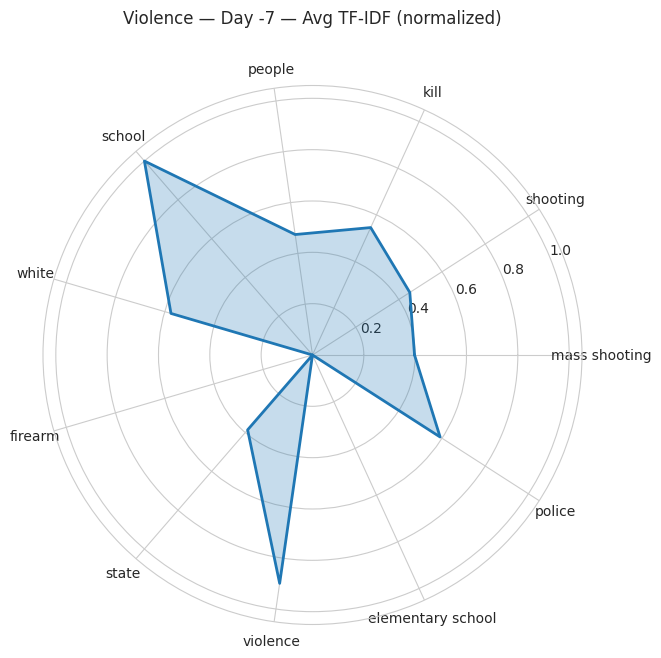

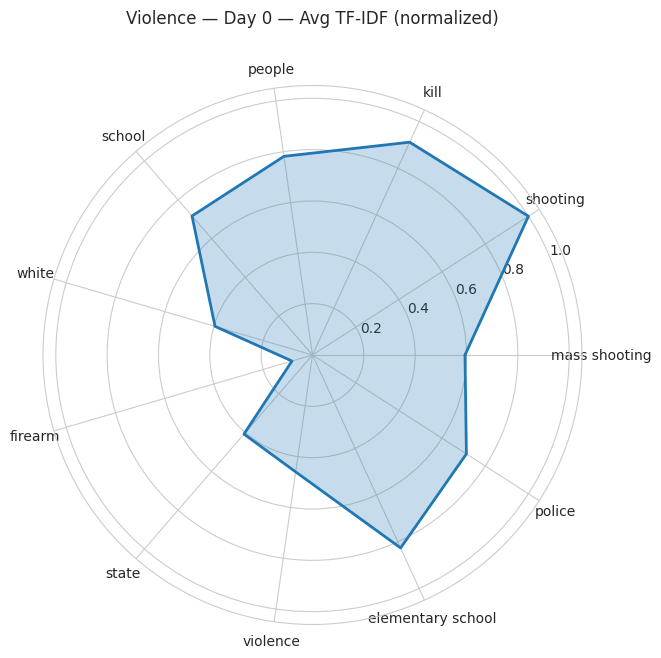

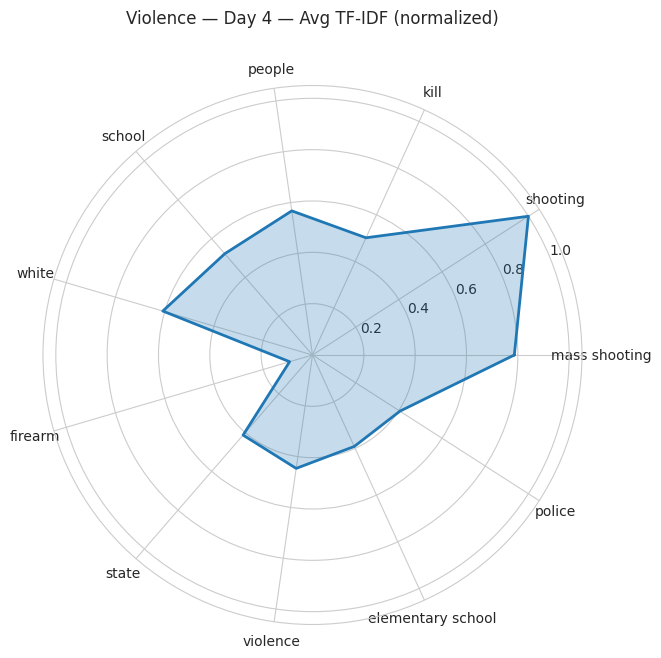

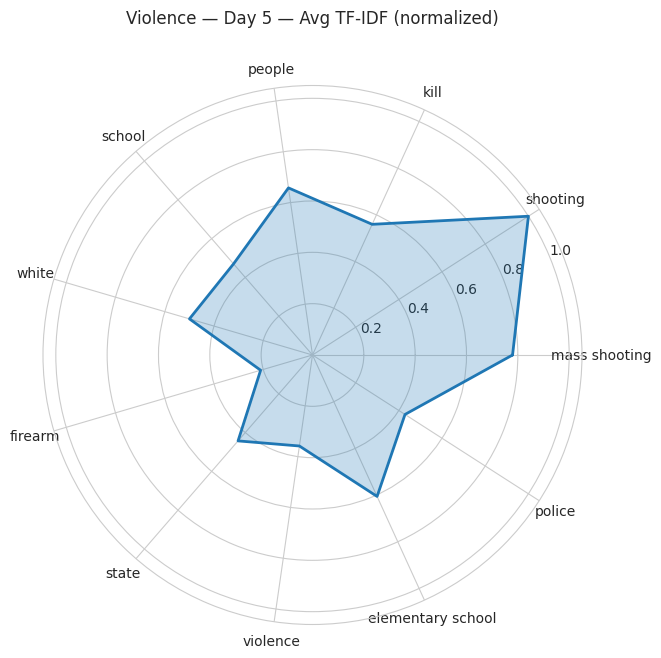

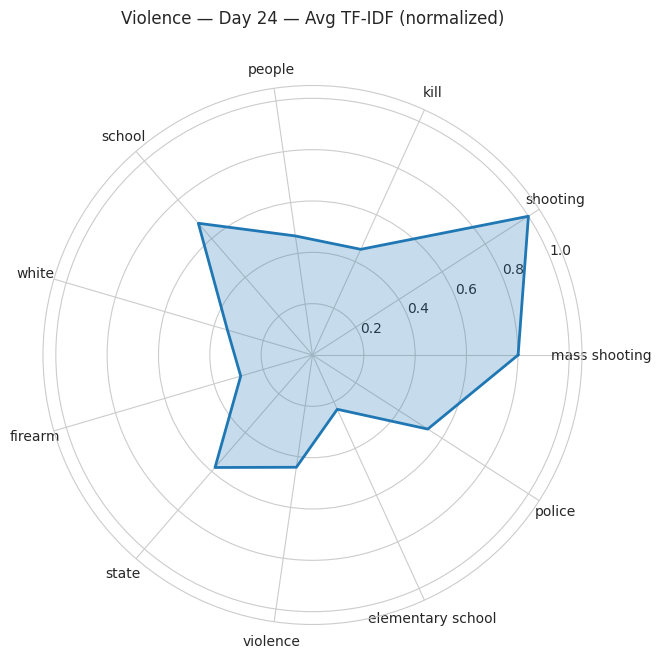

In [227]:
for day in sorted(radar_df.index):
    plot_radar_for_day(day, radar_df.loc[day], radar_df.columns, normalize=True)
